In [162]:
import pandas as pd
from NACE_helper import NACE_helper
import matplotlib.pyplot as plt

In [152]:
ds_2  = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_2/reports_subset_from_full_data_2_overview.csv")
ds_3  = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_overview.csv")

In [158]:
ds_3.loc[:,"NACE_lvl_3"] = ds_3["NACE"].apply(lambda x: NACE_helper.get_all_level(x)[3])

In [165]:
all_classes = ['01.5',
 '01.6',
 '03.1',
 '03.2',
 '21.1',
 '21.2',
 '26.1',
 '26.6',
 '64.1',
 '64.3',
 '64.9',
 '64.2',
 '66.1',
 '66.2',
 '66.3',
 '41.1',
 '41.2',
 '42.1',
 '42.2',
 '42.9',
 '58.1',
 '58.2',
 '61.1',
 '61.2',
 '77.1',
 '77.3',
 '81.3']
len(all_classes)

27

In [161]:
ds_3_relevant = ds_3[ds_3['NACE_lvl_3'].isin(all_classes)]
ds_3_relevant

,Unnamed: 0,Symbol,Name,Company is Active,Company Founded Date,Country of Primary Listing Iso3,CUSIP,Date Of First Trade,Entity Country HQ,Entity Credit Parent,...,Primary Equity Listing,Proper Name,Public Company,Region Ticker,Sec is Primary Issue,Sec Type,SEDOL,NACE_Letter,Report,NACE_lvl_3
2,2,ID1000167901,PT Cilacap Samudera Fishing Industry Tbk,0,1999.0,IDN,Y129H6108,20220527.0,IDN,@NA,...,BMBMZG,PT Cilacap Samudera Fishing Industry Tbk,1.0,ASHA-ID,0,SHARE,BMBMZG9,A,PT Cilacap Samudera Fishing Industry Tbk3.pdf,03.1
10,10,ARP331091024,Cresud SA,1,1936.0,ARG,P3311R127,19850102.0,ARG,001MSF-E,...,223338,Cresud SA,1.0,CRES-AR,1,SHARE,2233387,A,Cresud SA1.pdf,01.6
11,11,LU0611262873,KSG Agro SA,1,2010.0,POL,L5903L107,20110505.0,UKR,0BRK63-E,...,B42XFB,KSG Agro SA,1.0,KSG-PL,1,SHARE,B42XFB0,A,KSG Agro SA1.pdf,01.5
15,15,LK0297N00008,Kahawatte Plantations PLC,1,1992.0,LKA,Y44954108,19990610.0,LKA,081QN4-E,...,613927,Kahawatte Plantations PLC,1.0,KAHA.N0000-LK,1,SHARE,6139276,A,Kahawatte Plantations PLC1.pdf,01.6
16,16,INE594O01015,R J Bio-Tech Ltd.,0,2005.0,IND,Y73126107,20130925.0,IND,@NA,...,BF49P8,R J Bio-Tech Ltd.,1.0,536456-IN,0,SHARE,BF49P80,A,R J Bio-Tech Ltd.2.pdf,01.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,659,INE359A01012,Escorts Finance Limited,1,1987.0,IND,Y2296Y115,19981223.0,IND,@NA,...,616370,Escorts Finance Limited,1.0,511716-IN,1,SHARE,6163703,N,Escorts Finance Limited2.pdf,77.3
672,672,AU000000MMS5,Mcmillan Shakespeare Limited,1,1988.0,AUS,Q58998107,20040315.0,AUS,006FG8-E,...,B00G1Q,Mcmillan Shakespeare Limited,1.0,MMS-AU,1,SHARE,B00G1Q0,N,Mcmillan Shakespeare Limited1.pdf,77.1
682,682,TRAFFKRL91P0,QNB Finans Finansal Kiralama A.S.,1,1990.0,TUR,M4578P104,19940221.0,TUR,062BGT-E,...,B03MSM,QNB Finans Finansal Kiralama A.S.,1.0,QNBFL.E-TR,1,SHARE,B03MSM0,N,QNB Finans Finansal Kiralama A.S.1.pdf,77.3
687,687,US10948C1071,"BrightView Holdings, Inc.",1,2013.0,USA,10948C107,20180628.0,USA,0GL2M1-E,...,10948C10,"BrightView Holdings, Inc.",1.0,BV-US,1,SHARE,BG0ZML1,N,"BrightView Holdings, Inc.1.pdf",81.3


In [164]:
ds_3_relevant.groupby('NACE_lvl_3').size()

NACE_lvl_3
01.5     2
01.6     4
03.1     1
03.2     3
21.1     2
21.2     3
26.1     3
41.1     5
41.2    15
42.1     5
42.2    10
42.9     5
58.1     1
58.2    22
61.1     1
61.2     3
64.1    10
64.2     1
64.9    19
66.1     7
66.2     1
66.3     4
77.1     1
77.3     5
81.3     2
dtype: int64

<Axes: ylabel='NACE_lvl_3'>

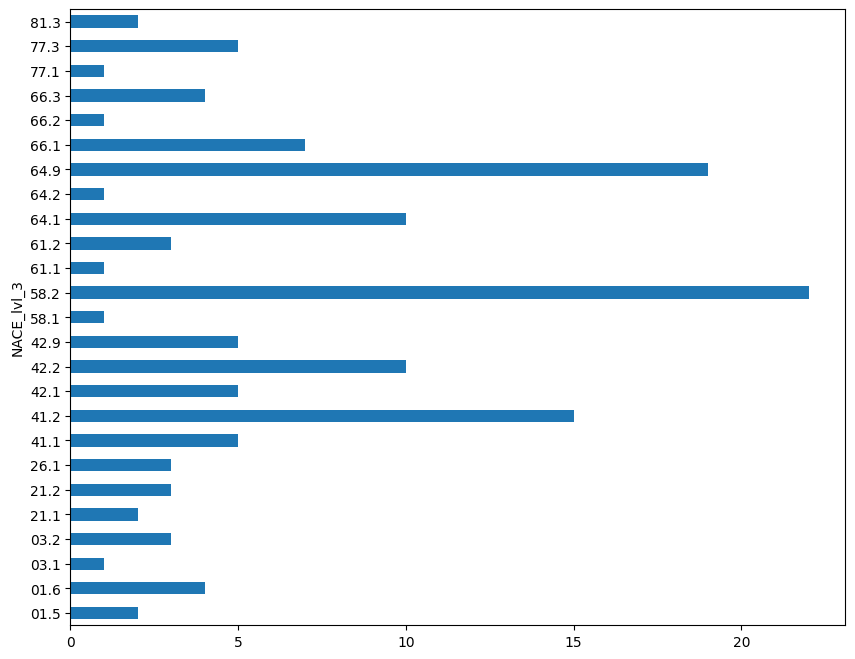

In [163]:
ds_3_relevant.groupby('NACE_lvl_3').size().plot(kind='barh', figsize=(10,8))

In [169]:
ds_3_relevant.to_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_for_backtracking.csv", index=False)

In [168]:
import shutil

for i, row in ds_3_relevant.iterrows():
    src = f"projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/PDFs/{row['Report']}"
    dst = f"projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/PDFs_for_backtracking/{row['Report']}"
    shutil.copyfile(src, dst)